# Data Structures

### Imports

In [1]:
import sys
sys.path.append("..")

import random

from trees.bst import BinarySearchTree
from trees.optimal_bst import build_optimal_bst
from trees.optimal_bst import request_frequencies
from trees.splay_tree import SplayTree

from workloads.uniform import generate_random_requests
from workloads.hot_set import generate_hotset_requests
from workloads.temporal import generate_temporal_requests

from visualization.results_visualization import plot_tree_metrics

### Functions

In [ ]:
def test_trees(n, requests, repeat=10, verbose=True):
    """
    Compare the performance of a BST, an optimal BST, and a splay tree.

    The BST and splay tree are initialized from independently shuffled
    insertion orders. Their performance metrics are averaged over the
    specified number of repetitions.

    Args:
        n: Number of keys.
        requests: Sequence of access requests.
        repeat: Number of independent repetitions used for averaging.
        verbose: Whether summary statistics should be printed.

    Returns:
        A tuple containing:

        - average BST search cost history,
        - optimal BST search cost history,
        - average splay tree search cost history,
        - average splay tree rotation count history.
    """

    bst_search_cost = [0 for _ in range(len(requests))]
    optimal_bst_search_cost = [0 for _ in range(len(requests))]
    splay_tree_search_cost = [0 for _ in range(len(requests))]
    splay_tree_rotations = [0 for _ in range(len(requests))]


    frequencies = request_frequencies(n, requests)
    optimal_bst = build_optimal_bst(n, frequencies)
    for i, request in enumerate(requests):
        optimal_bst.search(request)
        optimal_bst_search_cost[i] = optimal_bst.search_cost

    for _ in range(repeat):
        bst = BinarySearchTree()
        splay_tree = SplayTree()

        keys = list(range(n))
        random.shuffle(keys)

        for key in keys:
            bst.insert(key)
            splay_tree.insert(key)

        for i, request in enumerate(requests):
            bst.search(request)
            splay_tree.search(request)

            bst_search_cost[i] += bst.search_cost
            splay_tree_search_cost[i] += splay_tree.search_cost
            splay_tree_rotations[i] += splay_tree.rotations

    bst_search_cost = [x / repeat for x in bst_search_cost]
    splay_tree_search_cost = [x / repeat for x in splay_tree_search_cost]
    splay_tree_rotations = [x / repeat for x in splay_tree_rotations]

    if verbose:
        print("Optimal Binary Search Tree Search Cost:", int(optimal_bst_search_cost[-1]))
        print("Binary Search Tree Average Search Cost:", int(bst_search_cost[-1]))
        print("Splay Tree Average Search Cost:", int(splay_tree_search_cost[-1]))
        print("Splay Tree Average Rotation Count:", int(splay_tree_rotations[-1]))

    return (
        bst_search_cost,
        optimal_bst_search_cost,
        splay_tree_search_cost,
        splay_tree_rotations,
    )

### Uniform Distribution

Optimal Binary Search Tree Search Cost: 57185
Binary Search Tree Average Search Cost: 80567
Splay Tree Average Search Cost: 76767
Splay Tree Average Rotation Count: 66767


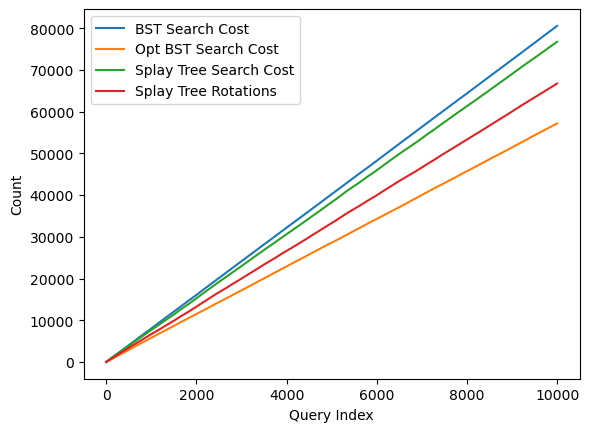

In [3]:
requests = generate_random_requests(100, 10000, 1)

BST_search_cost, opt_BST_search_cost, ST_search_cost, ST_rotations = test_trees(100, requests, 10, True)
plot_tree_metrics(BST_search_cost, opt_BST_search_cost, ST_search_cost, ST_rotations)

### Hot Set

**hot_fraction = 0.1** \
**hot_probability = 0.9**

Optimal Binary Search Tree Search Cost: 32166
Binary Search Tree Average Search Cost: 74669
Splay Tree Average Search Cost: 41988
Splay Tree Average Rotation Count: 31988


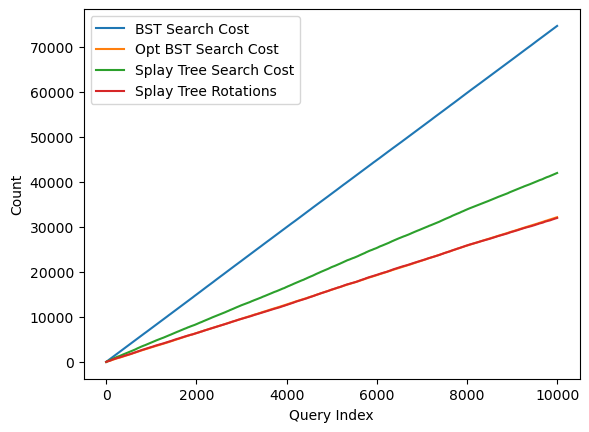

In [4]:
requests = generate_hotset_requests(100, 10000, 0.1, 0.9, 1)

BST_search_cost, opt_BST_search_cost, ST_search_cost, ST_rotations = test_trees(100, requests, 10, True)
plot_tree_metrics(BST_search_cost, opt_BST_search_cost, ST_search_cost, ST_rotations)

**hot_fraction = 0.3** \
**hot_probability = 0.9**

Optimal Binary Search Tree Search Cost: 43290
Binary Search Tree Average Search Cost: 74505
Splay Tree Average Search Cost: 58522
Splay Tree Average Rotation Count: 48522


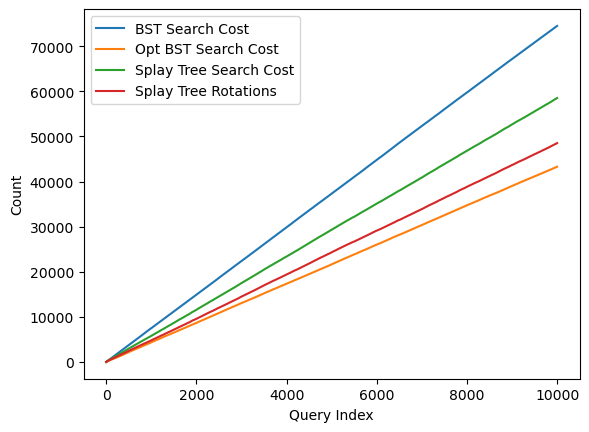

In [5]:
requests = generate_hotset_requests(100, 10000, 0.3, 0.9, 1)

BST_search_cost, opt_BST_search_cost, ST_search_cost, ST_rotations = test_trees(100, requests, 10, True)
plot_tree_metrics(BST_search_cost, opt_BST_search_cost, ST_search_cost, ST_rotations)

**hot_fraction = 0.5** \
**hot_probability = 0.9**

Optimal Binary Search Tree Search Cost: 56136
Binary Search Tree Average Search Cost: 71377
Splay Tree Average Search Cost: 75591
Splay Tree Average Rotation Count: 65591


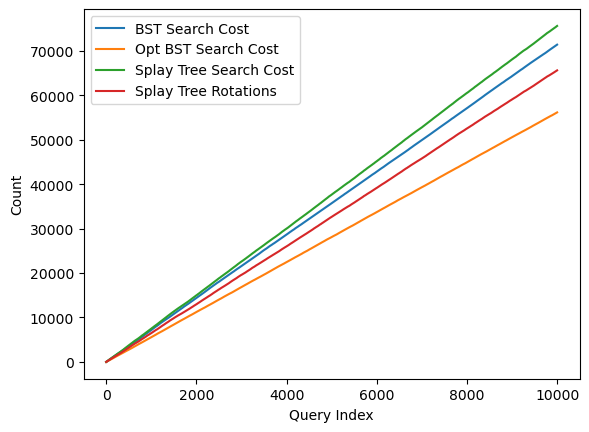

In [6]:
requests = generate_hotset_requests(100, 10000, 0.9, 0.9, 1)

BST_search_cost, opt_BST_search_cost, ST_search_cost, ST_rotations = test_trees(100, requests)
plot_tree_metrics(BST_search_cost, opt_BST_search_cost, ST_search_cost, ST_rotations)

### Temporal Locality

**p_repeat = 0.5**

Optimal Binary Search Tree Search Cost: 56910
Binary Search Tree Average Search Cost: 78345
Splay Tree Average Search Cost: 43995
Splay Tree Average Rotation Count: 33995


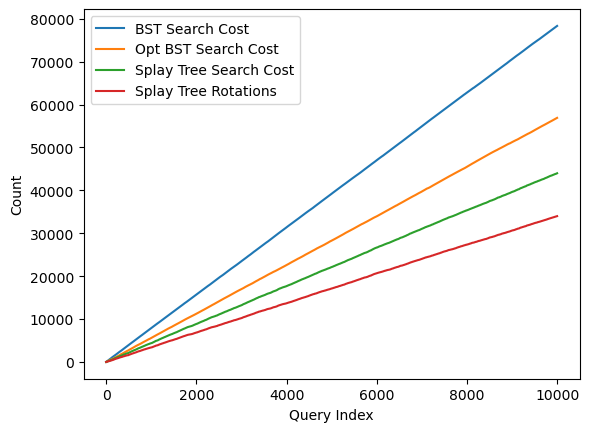

In [7]:
requests = generate_temporal_requests(100, 10000, p_repeat=0.5, dim=1)

BST_search_cost, opt_BST_search_cost, ST_search_cost, ST_rotations = test_trees(100, requests, 10, True)
plot_tree_metrics(BST_search_cost, opt_BST_search_cost, ST_search_cost, ST_rotations)

**p_repeat = 0.9**

Optimal Binary Search Tree Search Cost: 54485
Binary Search Tree Average Search Cost: 73234
Splay Tree Average Search Cost: 16726
Splay Tree Average Rotation Count: 6726


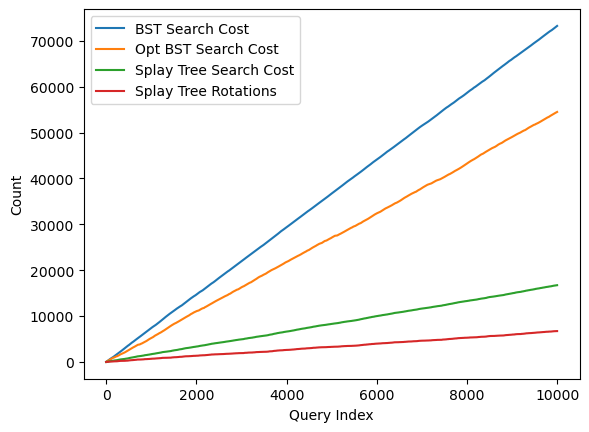

In [8]:
requests = generate_temporal_requests(100, 10000, p_repeat=0.9, dim=1)

BST_search_cost, opt_BST_search_cost, ST_search_cost, ST_rotations = test_trees(100, requests, 10, True)
plot_tree_metrics(BST_search_cost, opt_BST_search_cost, ST_search_cost, ST_rotations)